# Line Fitting

##### Install packeges

In [1]:
# %pip install numpy pandas matplotlib seaborn scikit-learn statsmodels jupyter
# probably already installed if you are using Anaconda distribution.
# if not activate your environment and then use: conda install numpy pandas matplotlib seaborn scikit-learn statsmodels jupyter


#### Import dependencies 

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

<h4>Initialize random sequence</h4>

In [3]:
a0 = 20
a1 = 10
x = np.linspace(-100,100,1000) # generate 1000 points, spaced regularly in [-100, 100]
y = a0 + a1*x + np.random.uniform(low=-1000,high=1000,size=x.shape)
data = pd.DataFrame({'x':x, 'y':y})

<div style="background-color: black; padding: 20px;">
<b>Questions:</b> <br>
1. Does x have errors?<br>
2. Does y have errors?<br>
3. What is the distribution of errors used?<br>
4. Is y a function of x, i.e. does a single x values implies a single y value? <br>
</div>

#### View the data

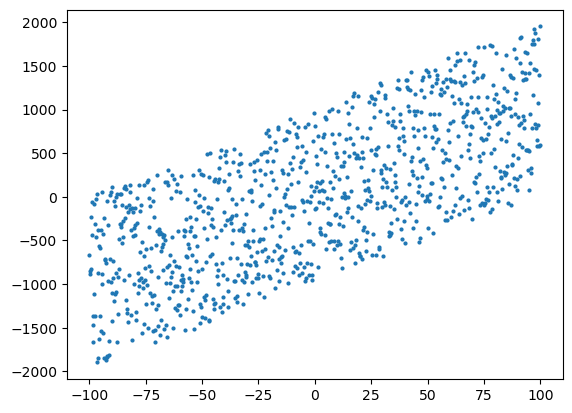

In [4]:
plt.scatter(x,y,s=4)
plt.show()

<h2>Fit  data to the polynomial</h2>  
polyfit performs least squares fit to find coefficients p for the polynomial of the given degree so that 
p(x) = p[0] * x**deg + ... + p[deg]

In [5]:
polynomial_coeff = np.polyfit(x, y, 1)
print('Polynom coefficients: a0='+str(polynomial_coeff[1])+' a1='+str(polynomial_coeff[0]))
poly_fit_object = np.poly1d(polynomial_coeff) 

Polynom coefficients: a0=23.51340478226023 a1=9.928300161655333


<div style="background-color: black; padding: 20px;">
<b>Questions:</b> <br>
1. Why is a0 coeff[1], and a1 coeff[0] ? <br>
2. What were the parameters of the line used to create the data? <br>
&ensp; &nbsp; Did the fit find the correct values? <br>
3. How changing the noise affects the fit? 
</div>

<h4>Plot fitted curve over the data</h4>

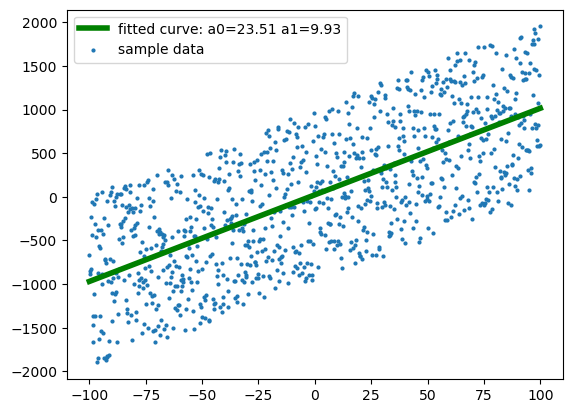

In [6]:
plt.plot(x,poly_fit_object(x),'g-', 
   label = 'fitted curve: a0={0:2.2f} a1={1:2.2f}'.format(polynomial_coeff[1], polynomial_coeff[0]),
   linewidth = 4)
plt.scatter(data['x'],data['y'],s=4, label = 'sample data')
plt.legend()
plt.show()

## Use linear regression to learn the curve coefficients


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

x = x.reshape((len(x), 1))  # Reshape x
y = y.reshape((len(y), 1))  # Reshape y

lm = LinearRegression() # note that the intercept is calculated by default, so we don't need to add a column of ones to x.
lm.fit(x, y)

# Predict y for calculating R^2
y_pred = lm.predict(x)

# Now print properly
print(f"Regression trained: R^2 = {r2_score(y, y_pred):3.3f}")  # Corrected to actually print R^2
print(f"y ~ {lm.intercept_[0]:2.2f} + {lm.coef_[0,0]:2.2f} * x")


Regression trained: R^2 = 0.502
y ~ 23.51 + 9.93 * x


<div style="background-color: black; padding: 20px;">
<b>Questions:</b> <br>
1. Are the values the same as in polyfit ? <br>
2. How changing the noise affects R^2? 
</div>

<h4>Plot fitted curve over the data</h4>

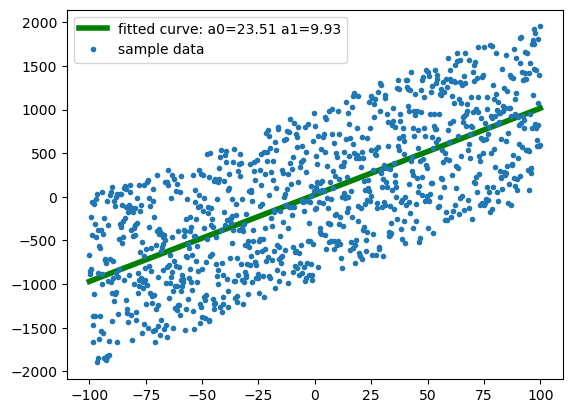

In [8]:
plt.plot(x,lm.predict(x),'g-', 
   label = 'fitted curve: a0={0:2.2f} a1={1:2.2f}'.format(lm.intercept_[0], lm.coef_[0][0]),
   linewidth = 4)
plt.plot(x,y,'.', label = 'sample data')
plt.legend()
plt.show()

## Use Ordinary Linear Regression (OLS) from statsmodels library
Note that OLS specification is: <br>
$y = {b_0}\times{x_0} + {b_1}\times{x_1} + \varepsilon$ 

This implies that $x_0=1$ must also be provided



In [9]:
import statsmodels.api as sm
X = sm.add_constant(x) # X 
sm_model = sm.OLS(y, X)
results = sm_model.fit()
print (results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     1007.
Date:                Mon, 25 May 2026   Prob (F-statistic):          2.05e-153
Time:                        12:27:31   Log-Likelihood:                -7766.5
No. Observations:                1000   AIC:                         1.554e+04
Df Residuals:                     998   BIC:                         1.555e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         23.5134     18.077      1.301      0.1

<div style="background-color: black; padding: 20px;">
<b>Questions:</b> <br>
1. Do we get the same parameters ? <br>
2. Do we get the same R^2? 
</div>

## Parabolic data

#### Generate data

In [10]:
# generate noisy data
a0 = 20
a1 = 10
a2 = 0.5
x = np.linspace(-100,100,1000)
y = a0 + a1*x + a2*x**2 + np.random.uniform(low=-1000,high=1000,size=x.shape)
data= pd.DataFrame({'y':y, 'x':x})
data.head()

,y,x
0,3746.810166,-100.000000
1,4194.541974,-99.799800
2,3870.961890,-99.599600
3,3968.606628,-99.399399
4,3839.233027,-99.199199


### Linear fit (polinomial)

Polynom coefficients: a0=1699.56, a1=10.03


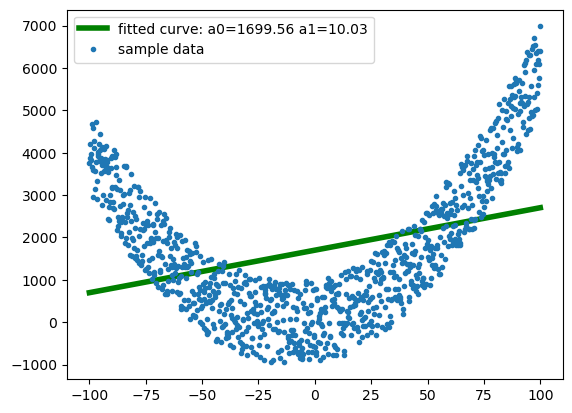

In [11]:
polynomial_coeff = np.polyfit(x, y, 1)
print('Polynom coefficients: a0={0:2.2f}, a1={1:2.2f}'.format(polynomial_coeff[1],polynomial_coeff[0]))
poly_fit_object = np.poly1d(polynomial_coeff)
# plot the data & the fit
plt.plot(x,poly_fit_object(x),'g-', 
       label = 'fitted curve: a0={0:2.2f} a1={1:2.2f}'.format(polynomial_coeff[1], polynomial_coeff[0]),
       linewidth = 4)
plt.plot(x,y,'.', label = 'sample data')
plt.legend()
plt.show()

<div style="background-color: black; padding: 20px;">
<b>Questions:</b> <br>
1. Look at the spread of the y values as a function of x. <br>
&ensp; &nbsp; Does it change? <br>
&ensp; &nbsp; Why is it so? <br>
</div>

###  Fit to second-degree polinomial:
$y=a + b\times{x} + c\times{x}^2$

Polynom coefficients:  a0=44.49, a1=10.03, a2=0.50
Original coefficients: a0=20.00, a1=10.00, a2=0.50


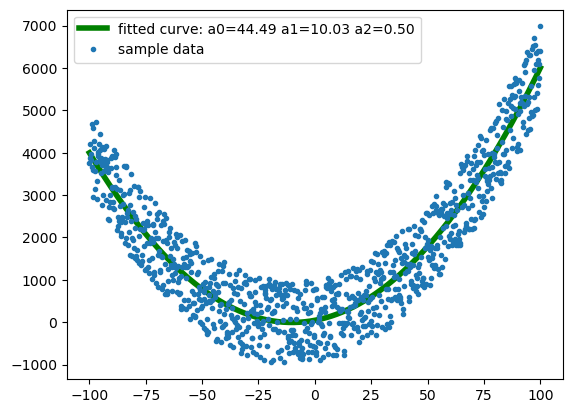

In [12]:
polynomial_coeff = np.polyfit(x, y, 2)
print('Polynom coefficients:  a0={0:2.2f}, a1={1:2.2f}, a2={2:2.2f}'.format(polynomial_coeff[2], polynomial_coeff[1],polynomial_coeff[0]))

# for reference, print the original coefficients:
print('Original coefficients: a0={0:2.2f}, a1={1:2.2f}, a2={2:2.2f}'.format(a0, a1, a2))

# we there is a difference between the original coefficients and the fitted coefficients?
# mainly because of the noise in the data.

# plot the data & the fit
plt.plot(x,np.polyval(polynomial_coeff,x),'g-', 
       label = 'fitted curve: a0={0:2.2f} a1={1:2.2f} a2={2:2.2f}'.format(polynomial_coeff[2], polynomial_coeff[1], polynomial_coeff[0]),
       linewidth = 4)
plt.plot(x,y,'.', label = 'sample data')
plt.legend()
plt.show()

<div style="background-color: black; padding: 20px;">
<b>Questions:</b> <br>
1. Is it a good fit? <br>
&ensp; &nbsp; look at estimated a0 vs. the original a0 <br>
</div>

### Regression analysis (2-nd order)
Now, try using regression with the model of: $$y = a+ bx + cx^2$$
X matrix has three columns: 
1. constant (all 1's)
2. x
3. x^2

In [13]:
data['x2'] = data['x']**2
data['intercept'] = 1
data.head()

,y,x,x2,intercept
0,3746.810166,-100.000000,10000.000000,1
1,4194.541974,-99.799800,9960.000040,1
2,3870.961890,-99.599600,9920.080240,1
3,3968.606628,-99.399399,9880.240601,1
4,3839.233027,-99.199199,9840.481122,1


In [14]:
import statsmodels.api as sm
sm_model = sm.OLS(data['y'], data[['intercept','x','x2']])
results = sm_model.fit()
print (results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     3670.
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        12:27:31   Log-Likelihood:                -7792.1
No. Observations:                1000   AIC:                         1.559e+04
Df Residuals:                     997   BIC:                         1.560e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     44.4943     27.834      1.599      0.1

## Use Sklearn linear regression to learn the curve coefficients

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. lets see if a line will fit the data well.
# We already know it won't, it is juest a demo of using linear regression with a low order model.
x = x.reshape((len(x), 1))  # Reshape x
y = y.reshape((len(y), 1))  # Reshape y

lm = LinearRegression()
lm.fit(x, y)

# Predict y for calculating R^2
y_pred = lm.predict(x)

# Now print properly
print("linear regression with a line")
print(f"Regression trained: R^2 = {r2_score(y, y_pred):3.3f}")  # Corrected to actually print R^2
print(f"y ~ {lm.intercept_[0]:2.2f} + {lm.coef_[0,0]:2.2f} * x")
print()

# 2. now use a 2nd degree polynomial regression, and see how it fits the data.
# we do not use polynomial regression directly, as we used before with np.polyfit.
# because it is not a linear regression model, and it is not implemented in scikit-learn.
# instead, we use linear regression, but on a transformed version of the data.
# we transform the data manually, by adding x^2 as a feature to the data, and then using linear regression on the new data.
x2 = x**2
X = np.column_stack([x, x2])
lm.fit(X, y)
y_pred = lm.predict(X)
print("linear regression with a 2nd degree polynomial")
print(f"Regression trained: R^2 = {r2_score(y, y_pred):3.3f}")
print(f"y ~ {lm.intercept_[0]:2.2f} + {lm.coef_[0,0]:2.2f} * x + {lm.coef_[0,1]:2.2f} * x^2")

# all 3 methods (np.polyfit, sm.OLS, sklearn linear regression with transformed data) should give very similar results.

linear regression with a line
Regression trained: R^2 = 0.117
y ~ 1699.56 + 10.03 * x

linear regression with a 2nd degree polynomial
Regression trained: R^2 = 0.880
y ~ 44.49 + 10.03 * x + 0.50 * x^2


<div style="background-color: black; padding: 20px;">
<b>Note:</b> <br>
 All 3 methods (np.polyfit, sm.OLS, sklearn linear regression with transformed data) should give very similar results. <br>
</div>

# Diamond Prices

#### Load the Diamond Data

In [16]:
data = pd.read_csv('local_data/diamonds.zip', index_col=0)
print(f"Loaded {data.shape[0]}x{data.shape[1]}")

Loaded 53940x10


## Model dianond price with Ordinary Least Squares: Polynomial regression
Assumption: the price depends quadratically on the diamodn size:<br>
$price = b_0 + b_1\times{carat} + b_2\times{carat^2}$

In [17]:
import statsmodels.api as sm

# the simplest possible regression model, with only one feature (carat) and no intercept.
data_for_fit = data[['price','carat']].copy()  

sm_model = sm.OLS(data_for_fit['price'], data_for_fit[['carat']])
ols_res = sm_model.fit()
print (ols_res.summary())

ols_res.params

                                 OLS Regression Results                                
Dep. Variable:                  price   R-squared (uncentered):                   0.881
Model:                            OLS   Adj. R-squared (uncentered):              0.881
Method:                 Least Squares   F-statistic:                          4.004e+05
Date:                Mon, 25 May 2026   Prob (F-statistic):                        0.00
Time:                        12:27:32   Log-Likelihood:                     -4.8462e+05
No. Observations:               53940   AIC:                                  9.692e+05
Df Residuals:                   53939   BIC:                                  9.692e+05
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

carat    5666.270066
dtype: float64

In [18]:
import statsmodels.api as sm

data_for_fit = data[['price','carat']].copy()

# using the model intercept + carat + carat^2 
data_for_fit['intercept'] = 1
data_for_fit['carat_2'] = data_for_fit['carat']**2


sm_model = sm.OLS(data_for_fit['price'], data_for_fit[['intercept','carat','carat_2']])
ols_res = sm_model.fit()
print (ols_res.summary())

ols_res.params

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.851
Method:                 Least Squares   F-statistic:                 1.540e+05
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        12:27:32   Log-Likelihood:            -4.7243e+05
No. Observations:               53940   AIC:                         9.449e+05
Df Residuals:                   53937   BIC:                         9.449e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept  -1832.5774     21.687    -84.500      0.0

intercept   -1832.577372
carat        6677.027342
carat_2       507.913267
dtype: float64

In [19]:
import statsmodels.formula.api as smf
def square(x):
    return x*x

def cube(x):
    return x*x*x

# now we use the formula API, which is more convenient, and allows us to use functions in the formula directly.
# note that the intercept is included by default in the formula API.
smf_model = smf.ols(formula='price ~ carat + square(carat) + cube(carat)',data=data)
ols_res = smf_model.fit()
print (ols_res.summary())

ols_res.params

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                 1.152e+05
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        12:27:32   Log-Likelihood:            -4.6976e+05
No. Observations:               53940   AIC:                         9.395e+05
Df Residuals:                   53936   BIC:                         9.396e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      -198.3337     30.014     -6.608

Intercept        -198.333748
carat             812.363922
square(carat)    5813.263738
cube(carat)     -1308.843780
dtype: float64

<div style="background-color: black; padding: 20px;">
<b>Discussion:</b> <br>
So, what model is best here?<br> 
How can we compare different models (with varying complexity) using the same mesure?<br>
In practice, it's usually best to use "test set" RMSE. It will tell us how good each model is in terms of generalization error.<br>
</div>


### Demonstrate prediction

C:\Users\ac050\AppData\Local\Temp\ipykernel_28016\2872263349.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_mean = data.groupby(categories, as_index=True).agg({'price':'mean','carat':'mean'})


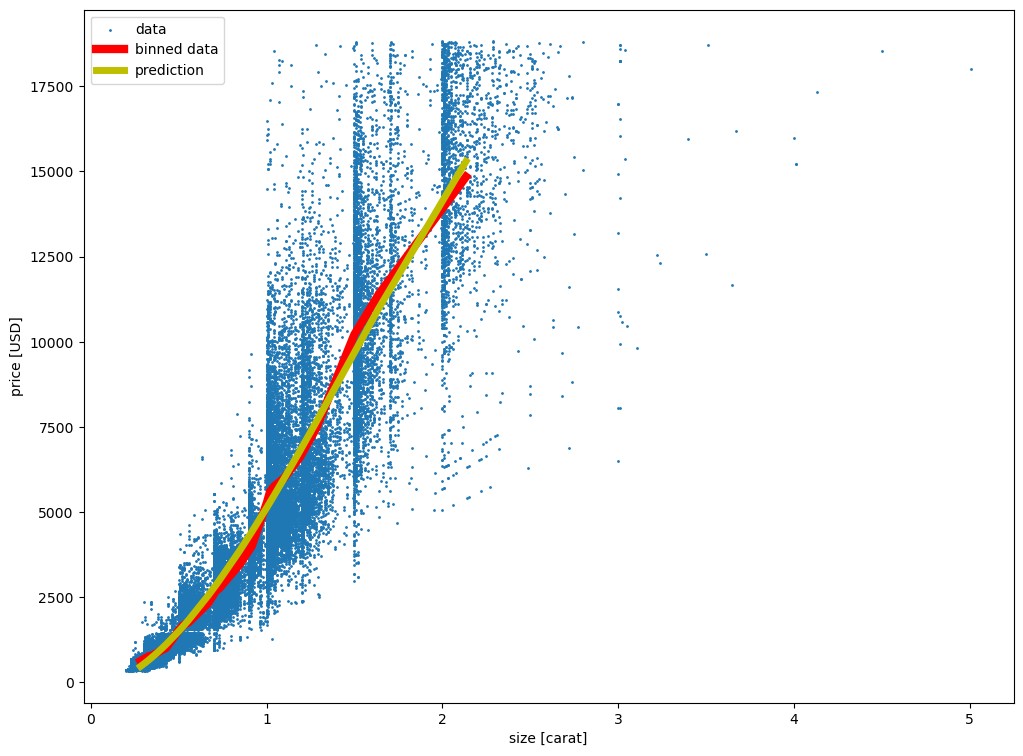

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,9))
# scatter plot of the original data
plt.scatter(data['carat'], data['price'],s=1, label='data')

# original data binned. 
categories, bins = pd.qcut(data['carat'], q=25, retbins=True)
price_mean = data.groupby(categories, as_index=True).agg({'price':'mean','carat':'mean'})
plt.plot(price_mean['carat'], price_mean['price'], color='r', linewidth=6, label='binned data')

# OLS prediction on the price mean of the binned data.
test_data= price_mean[['carat']]
test_data['carat_2'] = test_data['carat']**2
test_data['carat_3'] = test_data['carat']**3
test_data['intercept'] =1
ols_prediction = ols_res.predict(test_data[['intercept','carat','carat_2','carat_3']])
plt.plot(test_data['carat'],ols_prediction, color='y',linewidth=5, label='prediction')

plt.xlabel('size [carat]'); plt.ylabel('price [USD]'); plt.legend();

In [21]:
test_data.iloc[24]

carat        2.134576
carat_2      4.556414
carat_3      9.726011
intercept    1.000000
Name: (1.98, 5.01], dtype: float64

In [22]:
ols_res.predict(test_data.iloc[24])

(1.98, 5.01]    15293.52536
dtype: float64

### Multiple linear regression
<i>use many parameters to estimate price</i>
- price price in US dollars (\$326--\$18,823)
- carat weight of the diamond (0.2--5.01)
- cut quality of the cut (Fair, Good, Very Good, Premium, Ideal)
- color diamond colour, from J (worst) to D (best)
- clarity a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
- x length in mm (0--10.74)
- y width in mm (0--58.9)
- z depth in mm (0--31.8)
- depth total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)
- table width of top of diamond relative to widest point (43--95)


In [23]:
import statsmodels.formula.api as smf
def square(x):
    return x*x

def cube(x):
    return x*x*x

formula = '''price ~ 
    carat + square(carat) + cube(carat) + 
    C(cut) + C(color) + C(clarity) +
    depth + table + x + y + z
'''
smf_model_full = smf.ols(formula=formula,data=data)
ols_full_res = smf_model_full.fit()
print (ols_full_res.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                 2.736e+04
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        12:27:33   Log-Likelihood:            -4.5321e+05
No. Observations:               53940   AIC:                         9.065e+05
Df Residuals:                   53914   BIC:                         9.067e+05
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             804.3665    

### Compare errors for the two OLS models

#### Compute errors

In [24]:
# create 2 vectors of errors, one for the simple model (carat only) and one for the full model (all features).
errors_carat_only = data['price'] - ols_res.predict(data)
errors_full = data['price'] - ols_full_res.predict(data)
print('errors_carat_only\n', errors_carat_only)
print('\nerrors_full\n', errors_full)

errors_carat_only
 1          45.893096
2         109.493595
3          46.893096
4        -160.225879
5        -238.161948
            ...     
53936    -154.640875
53937    -154.640875
53938     -12.886813
53939   -1210.291147
53940    -371.731577
Length: 53940, dtype: float64

errors_full
 1        1430.946869
2         733.762573
3        -108.082061
4        1077.935272
5        3616.889234
            ...     
53936    -564.637457
53937    -300.639527
53938    -157.478812
53939     336.732134
53940     161.337759
Length: 53940, dtype: float64


Mean square errors: 
$MSE=\frac{1}{N}\sum{ {(X_i-{X_i}^{'})}^2}$

In [25]:
# mean absolute error (MAE) and root mean squared error (RMSE) for the two models.

MAE1 = errors_carat_only.abs().mean() 
MAE2 = errors_full.abs().mean() 
print(f'MAE: \n Model 1={MAE1}. \n Model 2={MAE2:2.2f}')
print()

RMSE1 = errors_carat_only.pow(2).mean()**0.5
RMSE2 = errors_full.pow(2).mean()**0.5
print(f'RMSE (root mean squared errors): \n Model 1={RMSE1}. \n Model 2={RMSE2:2.2f}')

MAE: 
 Model 1=842.7770280905237. 
 Model 2=710.07

RMSE (root mean squared errors): 
 Model 1=1465.5488649473386. 
 Model 2=1078.43


#### Plot Histogram of Errors

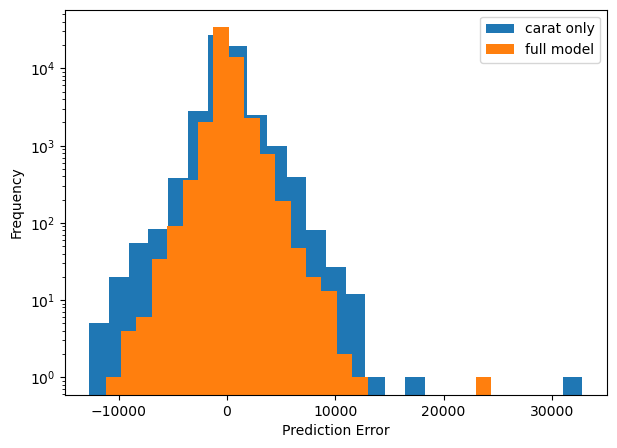

In [26]:
plt.figure(figsize=(7,5))
errors_carat_only.plot.hist(bins=25, ax=plt.gca(), label='carat only')
errors_full.plot.hist(bins=25, ax=plt.gca(), label='full model')
plt.yscale('log'); plt.xlabel('Prediction Error')
plt.legend(); plt.show()

<div style="background-color: black; padding: 20px;">
<b>Questions:</b> <br>
1. Is it expected? <br>
2. What does it mean? <br>
</div>

### Plot prediction vs. true value

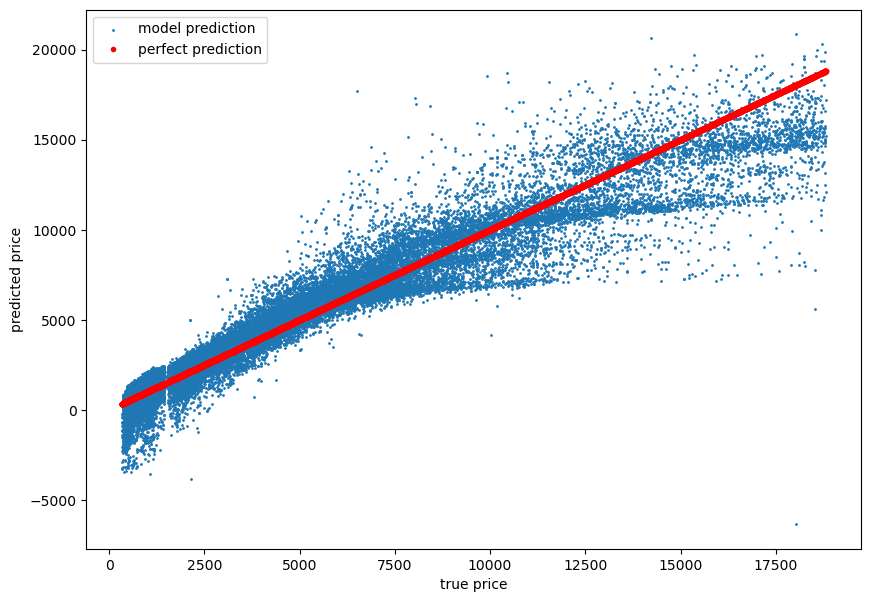

In [27]:
# scatter plot of the true price vs the predicted price for the full model.
plt.figure(figsize=(10,7))
plt.scatter(data['price'], ols_full_res.predict(data),s=1, label='model prediction')
plt.plot(data['price'],data['price'],'.r', label='perfect prediction')
plt.xlabel('true price');plt.ylabel('predicted price'); plt.legend()

plt.show()

# why do the model predictions deviate from the perfect prediction line?
# mainly because of the variability in the data itself:
# a wide range of data values result in similar prices!
# look again at the orginal data.

<div style="background-color: black; padding: 20px;">
<b>Questions:</b> <br>
2. What does the figure show? <br>
1. Why do the model predictions deviate from the perfect prediction line? <br>
</div>

#### Using SKlearn

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error 

data_encoded = pd.get_dummies(data, drop_first=True)
y = data_encoded['price']
X = data_encoded.drop(columns=['price']) 

# Fit model
lm = LinearRegression()
lm.fit(X, y)

# Predict
y_pred = lm.predict(X) 

# Calculate MSE
mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)

# Calculate RMSE
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")



Mean Squared Error: 1276545.174308389
RMSE: 1129.84


In [29]:
print('data.columns', data.columns)
print('data_encoded.columns', data_encoded.columns)

data.columns Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')
data_encoded.columns Index(['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut_Good',
       'cut_Ideal', 'cut_Premium', 'cut_Very Good', 'color_E', 'color_F',
       'color_G', 'color_H', 'color_I', 'color_J', 'clarity_IF', 'clarity_SI1',
       'clarity_SI2', 'clarity_VS1', 'clarity_VS2', 'clarity_VVS1',
       'clarity_VVS2'],
      dtype='object')


In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error
import numpy as np
data_selected= data[['price','carat', 'cut', 'color','depth']]
data_encoded = pd.get_dummies(data_selected, drop_first=True)
y = data_encoded['price']
X = data_encoded.drop(columns=['price']) 

# Fit model
lm = LinearRegression()
lm.fit(X, y)
# Predict
y_pred = lm.predict(X) 

mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)
mape = mean_absolute_percentage_error(y, y_pred) * 100
print(f"MAPE: {mape:.2f}%")

rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")

# to show how to use the sklearn function for RMSE we can calculate it again using the function directly.
RMSE = root_mean_squared_error(y, y_pred)
print(f"RMSE (using sklearn function): {RMSE:.2f}") 

Mean Squared Error: 2048370.9634815427
MAPE: 42.70%
RMSE: 1431.21
RMSE (using sklearn function): 1431.21


#### Gradient Descent
why use stotchastic gradient descent (SGD) instead of the analytical solution for linear regression?

On small datasets it is slower than the analytical solution that we have seen before 
but it is much faster to train on large datasets.
Some times it is the only option for training on large datasets, because the analytical
solution requires inverting a matrix, which is computationally expensive for large matrices.

In [31]:
from sklearn.linear_model import SGDRegressor

model = SGDRegressor(loss="squared_error", learning_rate="invscaling", eta0=0.01, max_iter=1000, verbose=1)
model.fit(X, y)
mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)

rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")

# should give very similar results to the linear regression model we used before.


-- Epoch 1
Norm: 181332477915.46, NNZs: 12, Bias: 3125536415.468566, T: 53940, Avg. loss: 1645731886275420219244544.000000, Objective: 1645734025256814310850560.000000
Total training time: 0.02 seconds.
-- Epoch 2
Norm: 125637903666.70, NNZs: 12, Bias: 2989261614.896982, T: 107880, Avg. loss: 636857684477273045991424.000000, Objective: 636858848768469571207168.000000
Total training time: 0.03 seconds.
-- Epoch 3
Norm: 23635607520.78, NNZs: 12, Bias: 1792997619.851290, T: 161820, Avg. loss: 180858614435136998998016.000000, Objective: 180858881103803206074368.000000
Total training time: 0.04 seconds.
-- Epoch 4
Norm: 11859206608.63, NNZs: 12, Bias: 1878384151.950715, T: 215760, Avg. loss: 61056213023992922112.000000, Objective: 61070059162914127872.000000
Total training time: 0.05 seconds.
-- Epoch 5
Norm: 8114144382.40, NNZs: 12, Bias: 1946101200.231375, T: 269700, Avg. loss: 5765214079184633856.000000, Objective: 5770048816207702016.000000
Total training time: 0.07 seconds.
-- Epoch 6


c:\Users\ac050\miniconda3\envs\ML\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [32]:
print(X.iloc[1])
model.predict(X.iloc[[1]])

carat             0.21
depth             59.8
cut_Good         False
cut_Ideal        False
cut_Premium       True
cut_Very Good    False
color_E           True
color_F          False
color_G          False
color_H          False
color_I          False
color_J          False
Name: 2, dtype: object


array([1232586.96315902])

## Regularization

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import linear_model as sklm

In [34]:
num_points = 12
# create a dataset with num_points points, where x is in the range [0, 2*pi], and y is a noisy sine function of x.
# add higher order terms of x to the dataset, up to x^16, to show how linear regression can fit
# a non-linear function by adding non-linear features.

df = pd.DataFrame({'x':np.array(range(0,num_points)) * 2/(num_points-1)*np.pi})
df['x2'] = df['x']**2

"""
df['x3'] = df['x']*df['x2']
df['x4'] = df['x']*df['x3']
df['x5'] = df['x']*df['x4']
df['x6'] = df['x']*df['x5']
df['x7'] = df['x']*df['x6']
df['x8'] = df['x']*df['x7']
df['x9'] = df['x']*df['x8']
df['x10'] = df['x']*df['x9']
df['x11'] = df['x']*df['x10']
df['x12'] = df['x']*df['x11']
df['x13'] = df['x']*df['x12']
df['x14'] = df['x']*df['x13']
df['x15'] = df['x']*df['x14']
df['x16'] = df['x']*df['x15']
"""

for i in range(3,17):
    df[f'x{i}'] = df['x']*df[f'x{i-1}']   


df['y_org'] = np.sin(df['x'].values) # the original y values without noise, which is a sine function of x.
df['y'] = df['y_org'] + 0.5 * np.random.normal(size=num_points) # adding normally distributed noise

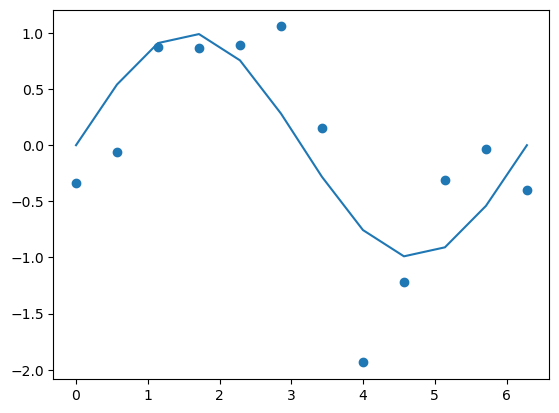

In [35]:
# plot the original data and the original function (without noise).
plt.plot(df['x'],df['y_org'])
plt.scatter(df['x'], df['y'] )
plt.show()

#### Polinomial regression
using scikit-learn linear regression by adding powers of x as features

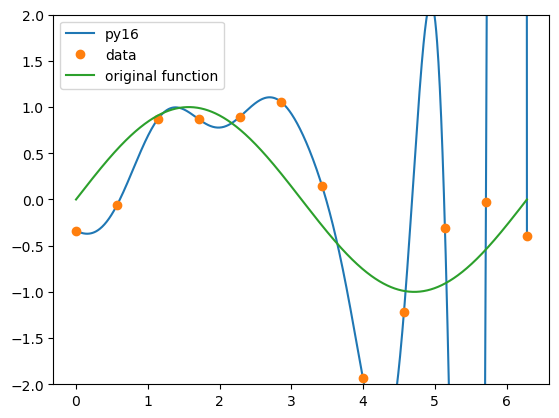

In [36]:
# fit linear regression models with different number of features, according to the polynomial degree of the features,
poly1 = sklm.LinearRegression().fit(df[['x']],df['y'])
poly2 = sklm.LinearRegression().fit(df.iloc[:,0:2],df['y'])
poly4 = sklm.LinearRegression().fit(df.iloc[:,0:4],df['y'])
poly8 = sklm.LinearRegression().fit(df.iloc[:,0:8],df['y'])
poly16 = sklm.LinearRegression().fit(df.iloc[:,0:16],df['y'])

# predict the y values for the original x values, using the fitted models, and add them to the dataframe.
df['py1'] = poly1.predict(df[['x']])
df['py2'] = poly2.predict(df.iloc[:,0:2])
df['py4'] = poly4.predict(df.iloc[:,0:4])
df['py8'] = poly8.predict(df.iloc[:,0:8])
df['py16'] = poly16.predict(df.iloc[:,0:16])


# note that we fitted the models using only a small number of points (num_points),
# but since the fits are actually a polynomial (with different degrees),
# we can show a much smoother version of the function.
# we just need to evaluate the polynomial on a finer grid of x values.
# e.g
x_fine = np.linspace(0, 2*np.pi, 1000)
y_fine = np.sin(x_fine) # for display purpose onle, the original function without noise, which is a sine function of x.

# demonstrate the fit of the 16 degree polynomial
# get the coefficients and the intercept of the polynomial fit with degree 16,
poly_coeff = poly16.coef_
intercept_ = poly16.intercept_


# creting the y of the 16th degree polynomial but using a loop
y_fine_py16 = np.zeros_like(x_fine)
for i in range(16):
    y_fine_py16 += poly_coeff[i]*x_fine**(i+1)
y_fine_py16 += intercept_


plt.plot(x_fine, y_fine_py16, label='py16')
plt.plot(df['x'], df['y'], 'o', label='data')
# show the result in y range of [-2, 2] to see the fit better.
plt.ylim(-2, 2) 
plt.plot(x_fine, y_fine, label='original function')
plt.legend()
plt.show()

# note, for high enough ploynomial we get a perfect fit to the training data, but the fit is very bad outside the training data (overfitting).

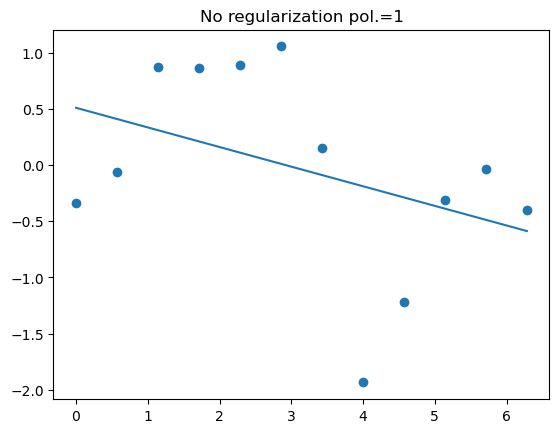

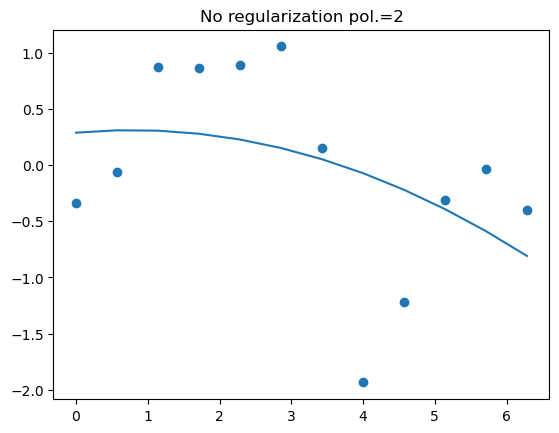

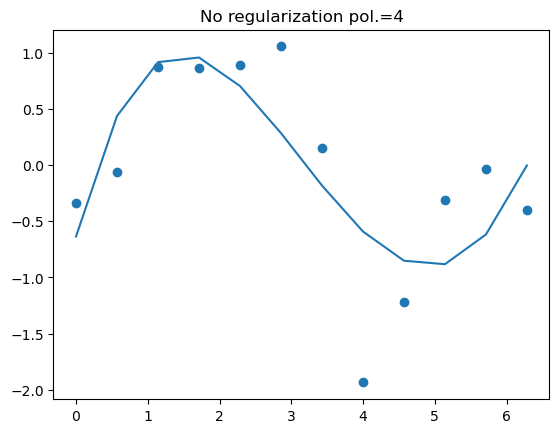

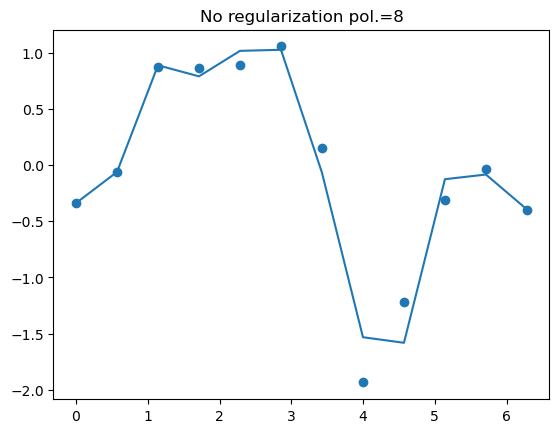

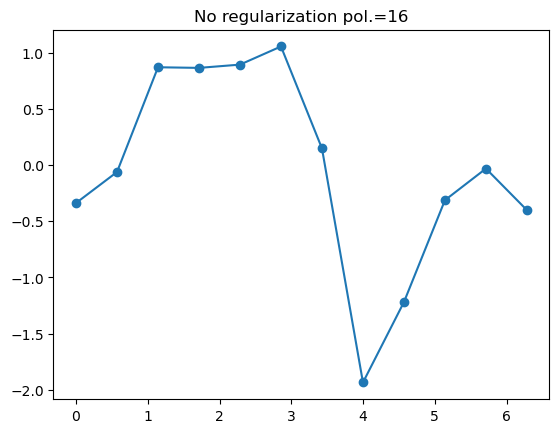

In [37]:
plt.plot(df['x'], df['py1'])
plt.scatter(df['x'], df['y'] )
plt.title('No regularization pol.=1')
plt.show()


plt.plot(df['x'], df['py2'])
plt.scatter(df['x'], df['y'] )
plt.title('No regularization pol.=2')
plt.show()


plt.plot(df['x'], df['py4'])
plt.scatter(df['x'], df['y'] )
plt.title('No regularization pol.=4')
plt.show()


plt.plot(df['x'], df['py8'])
plt.scatter(df['x'], df['y'] )
plt.title('No regularization pol.=8')
plt.show()

plt.plot(df['x'], df['py16'])
plt.scatter(df['x'], df['y'] )
plt.title('No regularization pol.=16')
plt.show()


#### Ridge Regularization

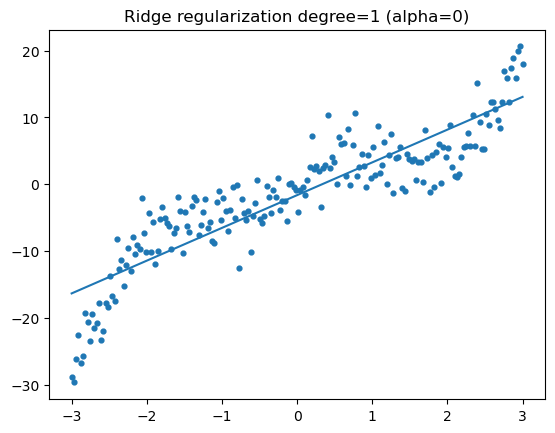

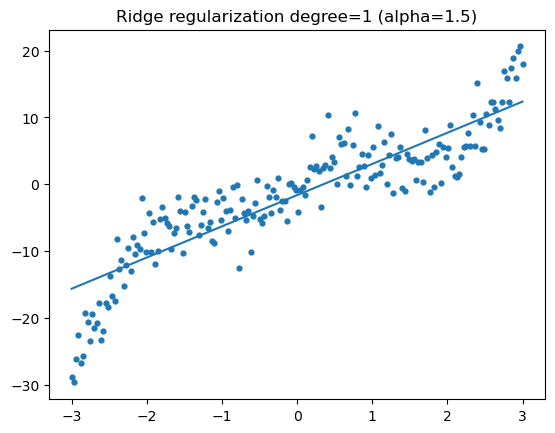

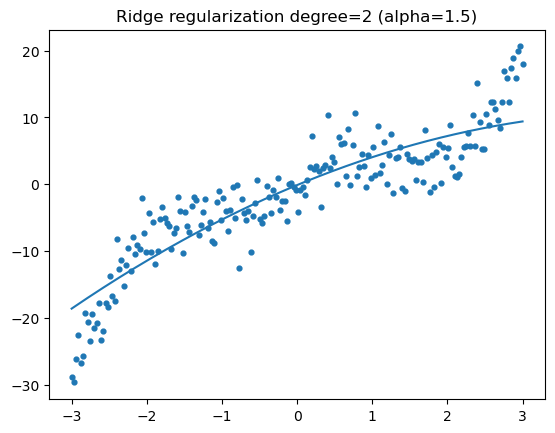

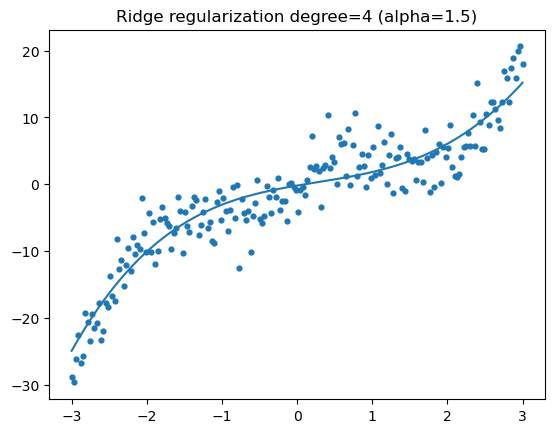

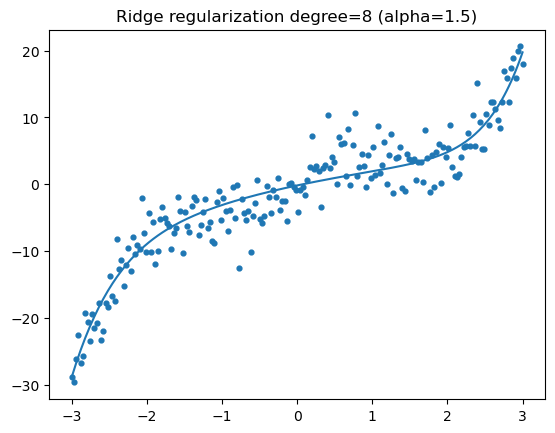

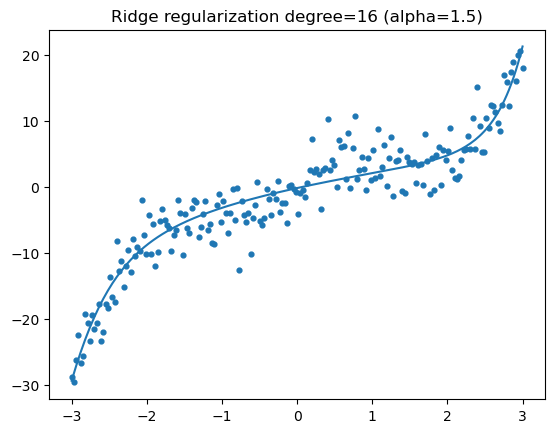

In [38]:
# === Ridge example (alpha=1.5) ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

# Synthetic nonlinear data
rng = np.random.RandomState(42)
x = np.linspace(-3, 3, 200)
y = (x**3 - 0.5*x**2) + 4*np.sin(2*x) + rng.normal(scale=3.0, size=x.shape)
df = pd.DataFrame({"x": x, "y": y})

degrees = [1, 2, 4, 8, 16]
alpha = 10

def ridge_pred(df, degree, alpha=alpha):
    pipe = Pipeline([
        # why bias = False? because we want to use the intercept of the Ridge model, and not add a column of ones to the data.
        ("poly",   PolynomialFeatures(degree=degree, include_bias=False)), 
        ("scale",  StandardScaler()),
        ("model",  Ridge(alpha=alpha, random_state=0)), # default is fit_intercept=True, so we don't need to add a column of ones to the data.
    ])
    return pipe.fit(df[["x"]], df["y"]).predict(df[["x"]])

# Add predictions as columns (py1, py2, py4, py8, py16)
df["py0"]  = ridge_pred(df, 1, alpha=0)
df["py1"]  = ridge_pred(df, 1)
df["py2"]  = ridge_pred(df, 2)
df["py4"]  = ridge_pred(df, 4)
df["py8"]  = ridge_pred(df, 8)
df["py16"] = ridge_pred(df, 16)

# why do we need to sort the x values?
# because we want to plot the predicted values in the correct order of x,
# and not in the order of the original data, in case it is not sorted.
order = np.argsort(df["x"].values) 
# Plots
plt.plot(df["x"].values[order], df["py0"].values[order])
plt.scatter(df["x"], df["y"], s=12)
plt.title("Ridge regularization degree=1 (alpha=0)")
plt.show()

plt.plot(df["x"].values[order], df["py1"].values[order])
plt.scatter(df["x"], df["y"], s=12)
plt.title("Ridge regularization degree=1 (alpha=1.5)")
plt.show()

plt.plot(df["x"].values[order], df["py2"].values[order])
plt.scatter(df["x"], df["y"], s=12)
plt.title("Ridge regularization degree=2 (alpha=1.5)")
plt.show()

plt.plot(df["x"].values[order], df["py4"].values[order])
plt.scatter(df["x"], df["y"], s=12)
plt.title("Ridge regularization degree=4 (alpha=1.5)")
plt.show()

plt.plot(df["x"].values[order], df["py8"].values[order])
plt.scatter(df["x"], df["y"], s=12)
plt.title("Ridge regularization degree=8 (alpha=1.5)")
plt.show()

plt.plot(df["x"].values[order], df["py16"].values[order])
plt.scatter(df["x"], df["y"], s=12)
plt.title("Ridge regularization degree=16 (alpha=1.5)")
plt.show()


Tips:
- If the Ridge curves are too wiggly/overfit, increase alpha (e.g., ×3).
- If they’re too flat/underfitting, decrease alpha (e.g., ÷3 or ×0.1).
- Standardize features (use StandardScaler) so alpha is comparable across degrees and datasets.
- As polynomial degree increases, raise alpha to keep the fit smooth.
- Tune alpha on a log scale (e.g., np.logspace(-4, 4, ...)) or use RidgeCV.
- Sort x before plotting to get smooth lines in 1D demos.
- With correlated features, Ridge stabilizes weights better than plain OLS.
- If you need sparsity (zeroed features), switch to Lasso or ElasticNet—not Ridge.

#### Lasso Regularization

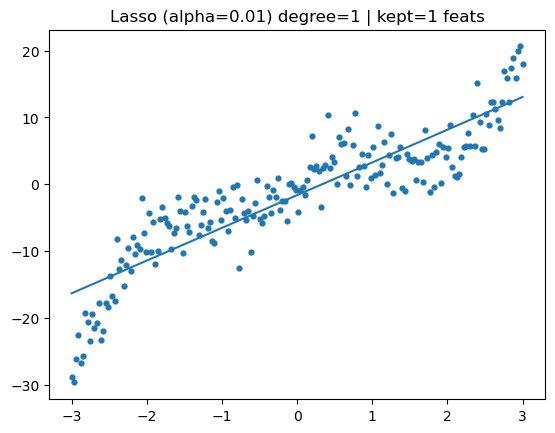

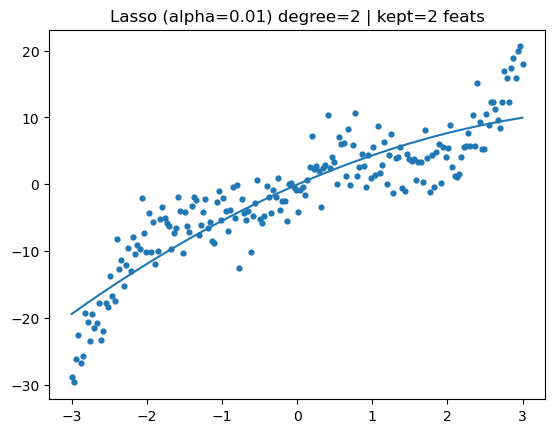

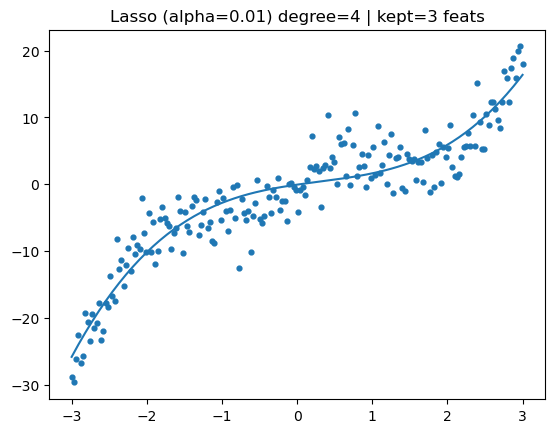

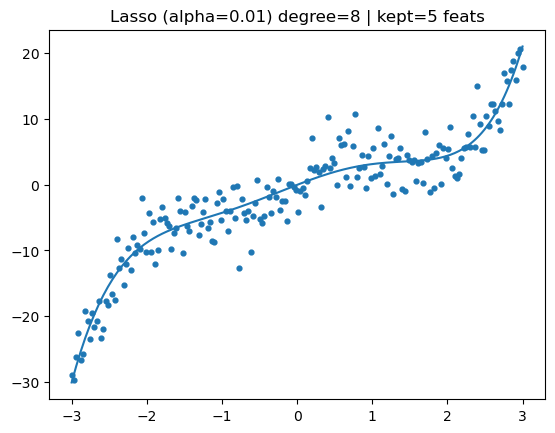

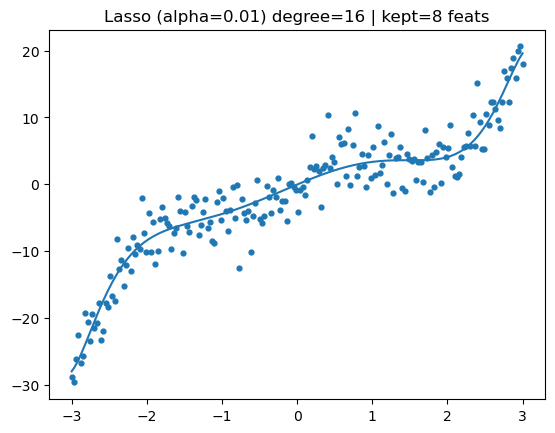

Lasso non-zero coefficients by degree: {1: 1, 2: 2, 4: 3, 8: 5, 16: 8}


In [39]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Lasso

# --- synthetic nonlinear data ---
rng = np.random.RandomState(42)
x = np.linspace(-3, 3, 200)
y = (x**3 - 0.5*x**2) + 4*np.sin(2*x) + rng.normal(scale=3.0, size=x.shape)
df = pd.DataFrame({"x": x, "y": y})
order = np.argsort(df["x"].values)

degrees = [1, 2, 4, 8, 16]
alpha_lasso = 0.01   # tune this: lower = more wiggly, higher = flatter

def fit_predict(model, deg):
    pipe = make_pipeline(
        PolynomialFeatures(degree=deg, include_bias=False),
        StandardScaler(),
        model
    )
    yhat = pipe.fit(df[["x"]], df["y"]).predict(df[["x"]])
    return pipe, yhat

# --- fit Lasso for all degrees ---
lasso_preds, lasso_kept = {}, {}
for d in degrees:
    l_model, l_pred = fit_predict(
        Lasso(alpha=alpha_lasso, max_iter=10000, random_state=0), d
    )
    lasso_preds[d] = l_pred
    # how many features Lasso keeps (non-zero after polynomial expansion)
    lasso_kept[d] = int(np.count_nonzero(l_model.named_steps["lasso"].coef_))

# --- plots ---
for d in degrees:
    plt.figure()
    plt.scatter(df["x"], df["y"], s=12)
    plt.plot(df["x"].values[order], lasso_preds[d][order])
    plt.title(f"Lasso (alpha={alpha_lasso}) degree={d} | kept={lasso_kept[d]} feats") # show how many features Lasso kept (non-zero after polynomial expansion)
    plt.show()

print("Lasso non-zero coefficients by degree:", lasso_kept)



Tips:
- If the Lasso lines are too flat, reduce alpha by 10× (e.g., 0.01 → 0.001).
- If they’re too wiggly/overfit, increase alpha.
- Keeping StandardScaler in the pipeline is crucial so alpha behaves consistently.

### ElasticNet Regularization

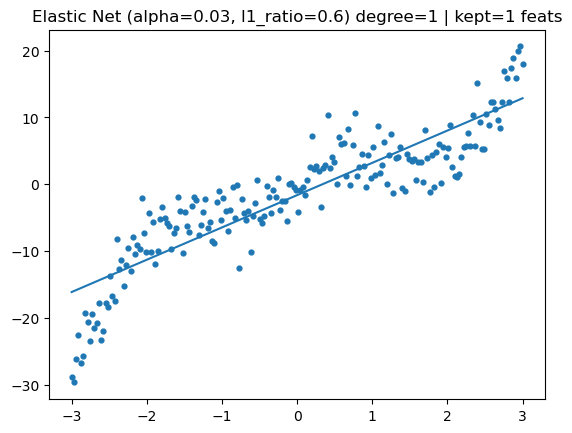

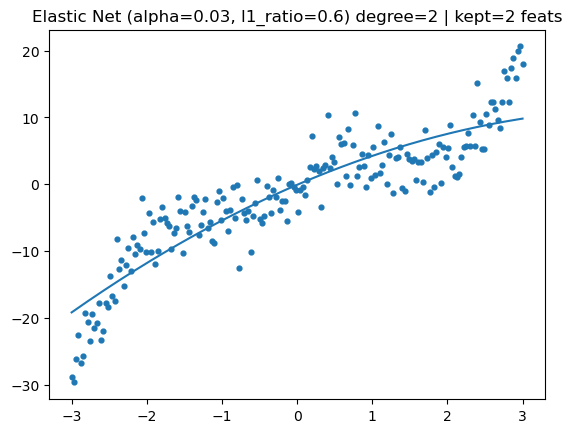

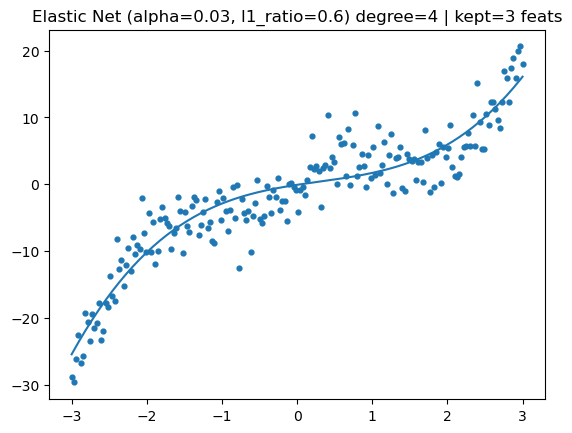

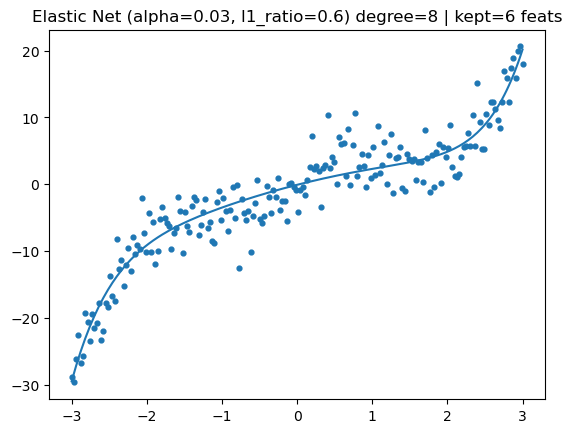

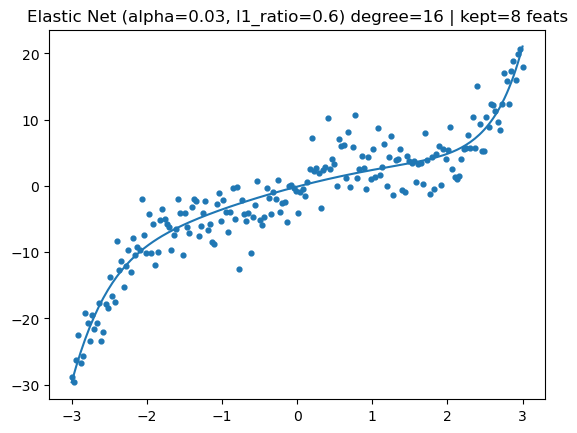

Elastic Net non-zero coefficients by degree: {1: 1, 2: 2, 4: 3, 8: 6, 16: 8}


In [40]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import ElasticNet

# --- synthetic nonlinear data ---
rng = np.random.RandomState(42)
x = np.linspace(-3, 3, 200)
y = (x**3 - 0.5*x**2) + 4*np.sin(2*x) + rng.normal(scale=3.0, size=x.shape)
df = pd.DataFrame({"x": x, "y": y})
order = np.argsort(df["x"].values)

degrees = [1, 2, 4, 8, 16]
alpha_en = 0.03        # overall regularization strength
l1_ratio_en = 0.6      # 1.0=Lasso, 0.0=Ridge

def fit_predict(model, deg):
    pipe = make_pipeline(
        PolynomialFeatures(degree=deg, include_bias=False),
        StandardScaler(),
        model
    )
    yhat = pipe.fit(df[["x"]], df["y"]).predict(df[["x"]])
    return pipe, yhat

# --- fit Elastic Net for all degrees ---
en_preds, en_kept = {}, {}
for d in degrees:
    en_model, en_pred = fit_predict(
        ElasticNet(alpha=alpha_en, l1_ratio=l1_ratio_en, max_iter=10000, random_state=0),
        d
    )
    en_preds[d] = en_pred
    # non-zero after polynomial expansion (feature selection effect)
    en_kept[d] = int(np.count_nonzero(en_model.named_steps["elasticnet"].coef_))

# --- plots: Elastic Net for each degree ---
for d in degrees:
    plt.figure()
    plt.scatter(df["x"], df["y"], s=12)
    plt.plot(df["x"].values[order], en_preds[d][order])
    plt.title(f"Elastic Net (alpha={alpha_en}, l1_ratio={l1_ratio_en}) degree={d} | kept={en_kept[d]} feats")
    plt.show()

print("Elastic Net non-zero coefficients by degree:", en_kept)


Tuning tips:
- If curves are too flat, decrease alpha_en (e.g., 0.03 → 0.01).
- If curves are too wiggly/overfit, increase alpha_en (e.g., 0.03 → 0.1).
- Use l1_ratio_en to blend selection vs. shrinkage:
- closer to 1.0 → more Lasso-like (more zeros),
- closer to 0.0 → more Ridge-like (fewer zeros).
- Keeping StandardScaler in the pipeline ensures alpha and l1_ratio behave consistently across degrees.

# Logit – Affairs

<h2>Database description</h2>
Description of Variables<br>
The dataset contains 6366 observations of 9 variables:
<ul>
<li>rate_marriage: woman's rating of her marriage (1 = very poor, 5 = very good)</li>
<li>age: woman's age</li>
<li>yrs_married: number of years married</li>
<li>children: number of children</li>
<li>religious: woman's rating of how religious she is (1 = not religious, 4 = strongly religious)</li>
<li>educ: level of education (9 = grade school, 12 = high school, 14 = some college, 16 = college graduate, 17 = some graduate school, 20 = advanced degree)</li>
<li>occupation: woman's occupation (1 = student, 2 = farming/semi-skilled/unskilled, 3 = "white collar", 4 = teacher/nurse/writer/technician/skilled, 5 = managerial/business, 6 = professional with advanced degree)</li>
<li>occupation_husb: husband's occupation (same coding as above)</li>
<li>affairs: time spent in extra-marital affairs</li>
</ul>
http://www.statsmodels.org/stable/datasets/generated/fair.html

<h4>Load the Data</h4>

In [41]:
import statsmodels.api as sm
dataset = sm.datasets.fair.load()

<h3>Prepare the Data</h3>

In [42]:
affairs_data = pd.DataFrame(dataset.exog, columns=dataset.exog_name)
affairs_data[dataset.endog_name] = dataset.endog
affairs_data.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [43]:
affairs_data['had_affairs'] = affairs_data['affairs'].apply(lambda x:1 if x>0 else 0)
affairs_data=affairs_data.drop(['affairs'], axis=1)

In [44]:
print(affairs_data.head())

   rate_marriage   age  yrs_married  children  religious  educ  occupation  \
0            3.0  32.0          9.0       3.0        3.0  17.0         2.0   
1            3.0  27.0         13.0       3.0        1.0  14.0         3.0   
2            4.0  22.0          2.5       0.0        1.0  16.0         3.0   
3            4.0  37.0         16.5       4.0        3.0  16.0         5.0   
4            5.0  27.0          9.0       1.0        1.0  14.0         3.0   

   occupation_husb  had_affairs  
0              5.0            1  
1              4.0            1  
2              5.0            1  
3              5.0            1  
4              4.0            1  


#### Replace occupation with string

In [45]:
def occupation_2_str(x, prefix):
    occupation_coding = ['student','farming', 'white collar', 'skilled', 'advanced degree','managerial']
    return prefix + '_' + occupation_coding[int(x)-1]
affairs_data['occupation_husb'] = affairs_data['occupation_husb'].apply(occupation_2_str,args=('husb',))
affairs_data['occupation'] = affairs_data['occupation'].apply(occupation_2_str,args=('wife',))

In [46]:
import statsmodels.formula.api as smf
formula='had_affairs ~ rate_marriage + age + yrs_married + children + religious+educ + C(occupation_husb) + C(occupation)' 
smf_model = smf.logit(formula=formula, data=affairs_data)
results = smf_model.fit()
results.summary()

Optimization terminated successfully.
         Current function value: 0.542911
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            had_affairs   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6349
Method:                           MLE   Df Model:                           16
Date:                Mon, 25 May 2026   Pseudo R-squ.:                  0.1365
Time:                        12:27:43   Log-Likelihood:                -3456.2
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                1.534e-222
===========================================================================================================
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   4.1973      0.353     11.896      0.000       3.506       4.889
C(occupation_husb)[T.husb_farming]         -0.0019      0.088     -0.021      0.983      -0.174       0.170
C(occupation_husb)[T.husb_managerial]       0.0104      0.120      0.087      0.931      -0.226       0.247
C(occupation_husb)[T.husb_skilled]         -0.0295      0.077     -0.384      0.701      -0.180       0.121
C(occupation_husb)[T.husb_student]         -0.1723      0.183     -0.944      0.345      -0.530       0.186
C(occupation_husb)[T.husb_white collar]     0.1118      0.118      0.951      0.342      -0.119       0.342
C(occupation)[T.wife_farming]              -0.6640      0.119     -5.573      0.000      -0.897      -0.430
C(occupation)[T.wife_managerial]            0.0538      0.246      0.219      0.827      -0.428       0.535
C(occupation)[T.wife_skilled]              -0.5828      0.105     -5.574      0.000      -0.788      -0.378
C(occupation)[T.wife_student]              -1.0542      0.447     -2.360      0.018      -1.930      -0.179
C(occupation)[T.wife_white collar]         -0.3515      0.094     -3.745      0.000      -0.535      -0.168
rate_marriage                              -0.7102      0.031    -22.560      0.000      -0.772      -0.649
age                                        -0.0613      0.010     -5.936      0.000      -0.082      -0.041
yrs_married                                 0.1080      0.011      9.836      0.000       0.086       0.129
children                                    0.0156      0.032      0.488      0.625      -0.047       0.078
religious                                  -0.3754      0.035    -10.766      0.000      -0.444      -0.307
educ                                       -0.0017      0.017     -0.099      0.921      -0.036       0.032
===========================================================================================================
"""

#### Accessing regression parameters

In [47]:
# exponential of the coefficients gives the odds ratio, which is more interpretable in logistic regression.
# if the odds ratio is greater than 1, it means that the feature increases the odds of having an affair, and if it is less than 1, it means that the feature decreases the odds of having an affair.
# for example, if the odds ratio of age is 0.9, it means that for every year increase in age, the odds of having an affair decreases by 10%.
# if the odds ratio of rate_marriage is 1.5, it means that for every unit increase in rate_marriage, the odds of having an affair increases by 50%.
odds_ratios = np.exp(results.params[1:]) # dont include the intercept in the odds ratios, because it is not interpretable.
print("Odds Ratios:\n", odds_ratios)


Odds Ratios:
 C(occupation_husb)[T.husb_farming]         0.998120
C(occupation_husb)[T.husb_managerial]      1.010489
C(occupation_husb)[T.husb_skilled]         0.970942
C(occupation_husb)[T.husb_student]         0.841702
C(occupation_husb)[T.husb_white collar]    1.118338
C(occupation)[T.wife_farming]              0.514809
C(occupation)[T.wife_managerial]           1.055292
C(occupation)[T.wife_skilled]              0.558333
C(occupation)[T.wife_student]              0.348472
C(occupation)[T.wife_white collar]         0.703619
rate_marriage                              0.491532
age                                        0.940561
yrs_married                                1.114021
children                                   1.015768
religious                                  0.687024
educ                                       0.998276
dtype: float64


In [48]:
affairs_data.columns

Index(['rate_marriage', 'age', 'yrs_married', 'children', 'religious', 'educ',
       'occupation', 'occupation_husb', 'had_affairs'],
      dtype='object')

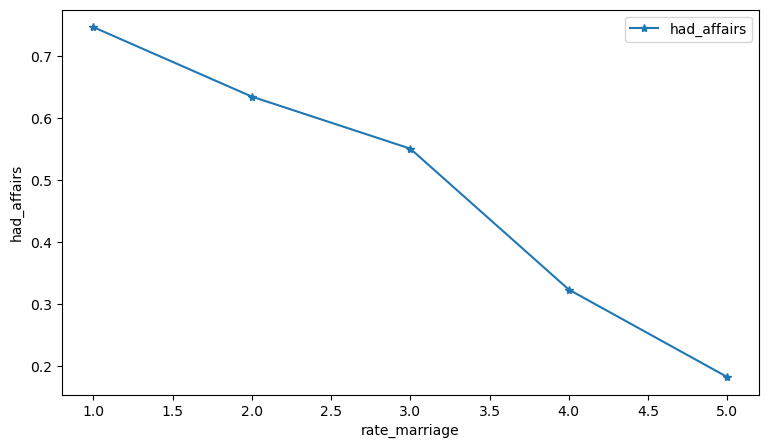

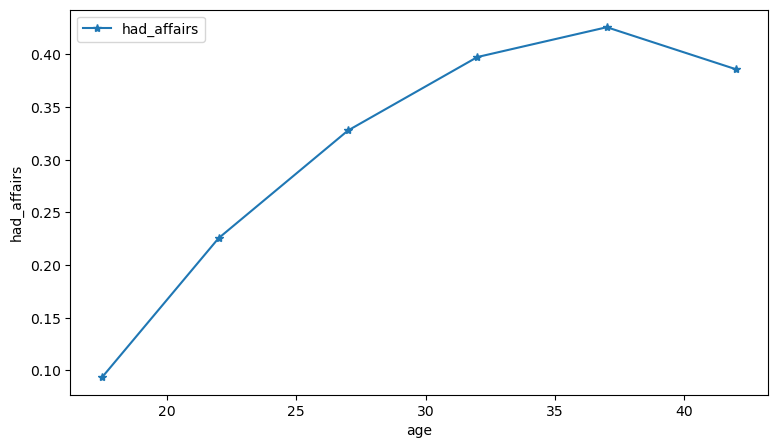

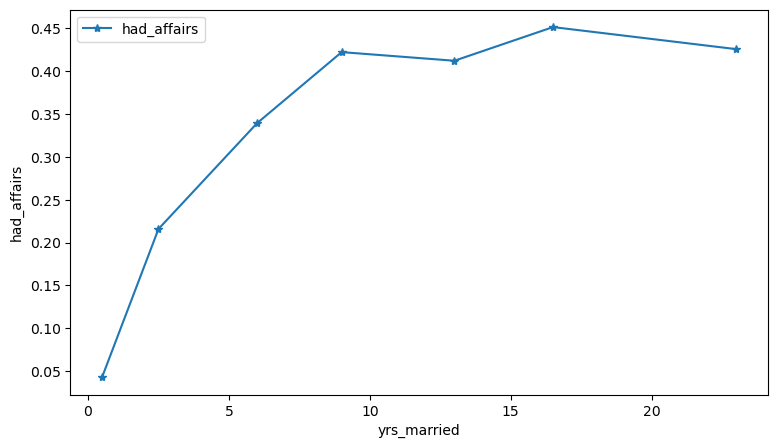

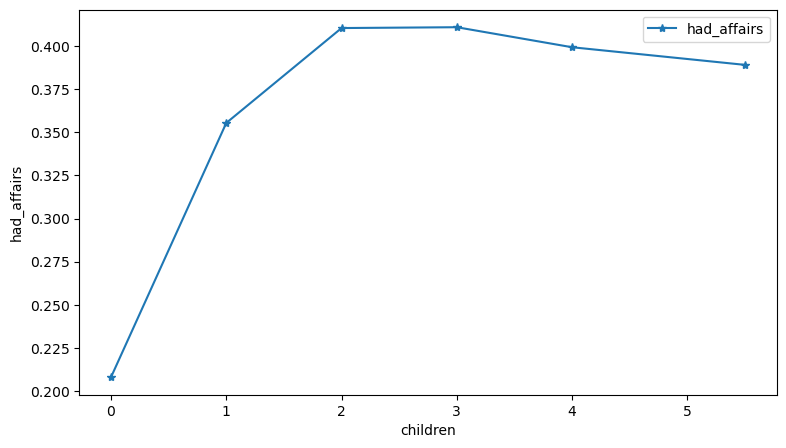

In [49]:
for attribute_name in ['rate_marriage','age','yrs_married','children']:
    mean_over_attribute = affairs_data.groupby(attribute_name).agg({attribute_name:'mean', 'had_affairs':'mean'})
    ax = mean_over_attribute.plot(x=attribute_name, y='had_affairs',figsize=(9,5), marker='*')
    ax.set_xlabel(attribute_name); ax.set_ylabel('had_affairs')

In [50]:
attribute_names = ['rate_marriage','age','yrs_married','children']
corrcoef = np.corrcoef(affairs_data[attribute_names].T)
print('Cross-correlation matrix:\n{0}'.format(attribute_names))
print(corrcoef)

Cross-correlation matrix:
['rate_marriage', 'age', 'yrs_married', 'children']
[[ 1.         -0.11112684 -0.12897845 -0.1291612 ]
 [-0.11112684  1.          0.89408184  0.67390214]
 [-0.12897845  0.89408184  1.          0.7728057 ]
 [-0.1291612   0.67390214  0.7728057   1.        ]]


## Logit using sklearn

In [51]:
from sklearn.linear_model import LogisticRegression

y = affairs_data['had_affairs']
X = affairs_data.drop('had_affairs',axis=1)
X = pd.get_dummies(X)
log_reg = LogisticRegression(max_iter=1000).fit(X,y)

In [52]:
log_reg.score(X,y)

0.7262016965127238

In [53]:
X.columns


Index(['rate_marriage', 'age', 'yrs_married', 'children', 'religious', 'educ',
       'occupation_wife_advanced degree', 'occupation_wife_farming',
       'occupation_wife_managerial', 'occupation_wife_skilled',
       'occupation_wife_student', 'occupation_wife_white collar',
       'occupation_husb_husb_advanced degree', 'occupation_husb_husb_farming',
       'occupation_husb_husb_managerial', 'occupation_husb_husb_skilled',
       'occupation_husb_husb_student', 'occupation_husb_husb_white collar'],
      dtype='object')

In [54]:
# use the fitted model to predict the probability of having an affair for the first, second and last data points in the dataset.

X0 = pd.DataFrame([X.iloc[0]], columns=X.columns)
X1 = pd.DataFrame([X.iloc[1]], columns=X.columns)
Xend = pd.DataFrame([X.iloc[-1]], columns=X.columns)

print(X0.values)
print(X1.values)
print(Xend.values)

print(log_reg.predict(X0))
print(log_reg.predict(X1))
print(log_reg.predict(Xend))

[[3.0 32.0 9.0 3.0 3.0 17.0 False True False False False False True False
  False False False False]]
[[3.0 27.0 13.0 3.0 1.0 14.0 False False False False False True False
  False False True False False]]
[[4.0 22.0 2.5 0.0 2.0 16.0 False True False False False False False
  False False True False False]]
[0]
[1]
[0]


In [55]:
affairs_data = pd.DataFrame(dataset.exog, columns=dataset.exog_name)
affairs_data[dataset.endog_name] = dataset.endog
affairs_data.head()


,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [56]:
from sklearn.linear_model import LinearRegression

y = affairs_data['affairs']
X = affairs_data.drop('affairs',axis=1)
X = pd.get_dummies(X)
lin_reg = LinearRegression().fit(X,y)

In [57]:
X1 = pd.DataFrame([X.iloc[1]], columns=X.columns)

lin_reg.predict(X1)

array([1.43522002])